# ДЗ №1 СУНЦ МГУ - Numpy practice

**Среда:** Python 3.14.7. Локальные модули `functions.py` и `functions_vectorized.py` повторно импортируются при каждом запуске ячейки с решением.


### Туториальные задачи
__(9 баллов)__

Ниже приведены задачи на работу с numpy-массивами. Для каждой из задач нужно привести 2 реализации: одна без использования numpy (cчитайте, что там, где на входе или выходе должны быть numpy array, будут просто списки), а вторая полностью векторизованная (без использования питоновских циклов/map/list comprehension). Невекторизованная реализация каждой из задач оценивается в __0.5 балла__, векторизованная – в __1 балл__.

Реализации без использования векторизации нужно записать в файл functions.py, а векторизованные &mdash; в файл functions_vectorized.py

Для каждой задачи, приведённой ниже сравните скорость работы невекторизованной и векторизованной реализации. С помощью пакета matplotlib постройте графики времени работы в зависимости от размера данных. __Графики должны выглядеть опрятно!__ То есть должны быть подписаны оси, названия графиков, и т.д. Например, ниже представлены хороший и плохой графики:

In [ ]:
#Доп.балы

* __Задача 1__: Подсчитать произведение ненулевых элементов на диагонали прямоугольной матрицы.  
 Например, для X = np.array([[1, 0, 1], [2, 0, 2], [3, 0, 3], [4, 4, 4]]) ответ – 3.

C:\Users\programma\AppData\Local\Temp\ipykernel_18540\4171128558.py:42: RuntimeWarning: overflow encountered in scalar multiply
  product *= val


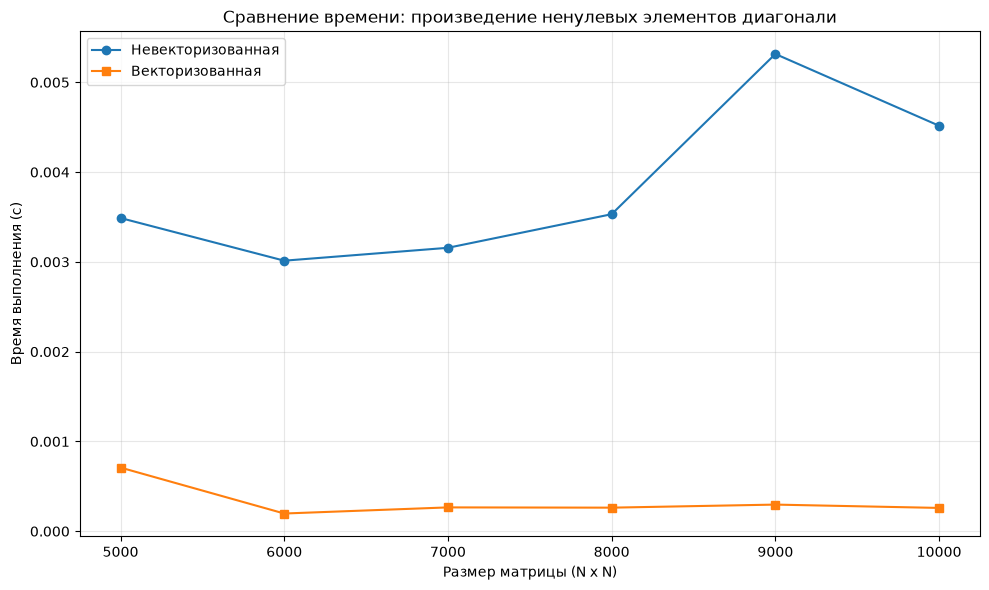

In [4]:
import time
import numpy as np
import matplotlib.pyplot as plt

def prod_non_zero_diag_vec(x):
    """Compute product of nonzero elements from matrix diagonal.

    input:
    x -- 2-d numpy array
    output:
    product -- integer number


    Vectorized implementation.
    """

    rows, cols = x.shape
    n = min(rows, cols)
    diag = np.diag(x[:n, :n]) 
    non_zero = diag[diag != 0]
    return np.prod(non_zero)


def prod_non_zero_diag(x):
    """Compute product of nonzero elements from matrix diagonal.

    input:
    x -- 2-d numpy array
    output:
    product -- integer number


    Not vectorized implementation.
    """

    rows, cols = x.shape
    n = min(rows, cols)
    product = 1
    for i in range(n):
        val = x[i, i]
        if val != 0:
            product *= val
    return product

sizes = [5000, 6000, 7000, 8000, 9000, 10000]

times_non_vec = []
times_vec = []

for n in sizes:
    X = np.random.randint(0, n/5, size=(n, n))
    
    start = time.perf_counter()
    prod_non_zero_diag(X)
    times_non_vec.append(time.perf_counter() - start)
    
    start = time.perf_counter()
    prod_non_zero_diag_vec(X)
    times_vec.append(time.perf_counter() - start)

plt.figure(figsize=(10, 6))
plt.plot(sizes, times_non_vec, marker='o', label='Невекторизованная')
plt.plot(sizes, times_vec, marker='s', label='Векторизованная')
plt.title('Сравнение времени: произведение ненулевых элементов диагонали')
plt.xlabel('Размер матрицы (N x N)')
plt.ylabel('Время выполнения (с)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

 
 
* __Задача 2__: Даны два вектора x и y. Проверить, задают ли они одно и то же мультимножество.  
  Например, для x = np.array([1, 2, 2, 4]), y = np.array([4, 2, 1, 2]) ответ – True.
  
  


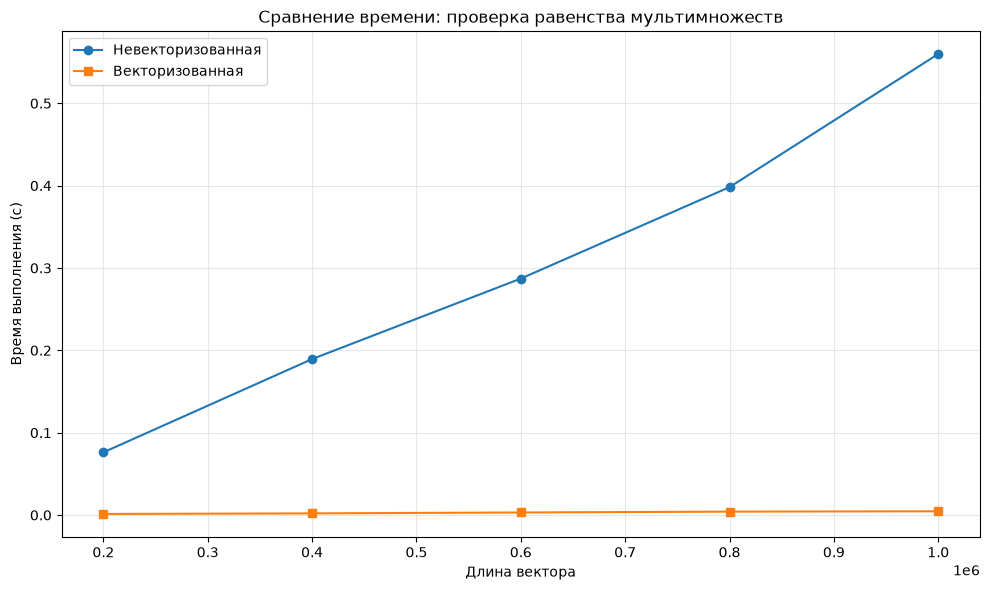

In [2]:
import time
import numpy as np
import matplotlib.pyplot as plt


def are_multisets_equal(x, y):
    """Return True if both vectors create equal multisets.

    input:
    x, y -- 1-d numpy arrays
    output:
    True if multisets are equal, False otherwise -- boolean

    Not vectorized implementation.
    """
    return sorted(x) == sorted(y)


def are_multisets_equal_vec(x, y):
    """Return True if both vectors create equal multisets.

    input:
    x, y -- 1-d numpy arrays
    output:
    True if multisets are equal, False otherwise -- boolean

    Vectorized implementation.
    """
    if x.shape != y.shape:
        return False
    return np.array_equal(np.sort(x), np.sort(y))


sizes = [200000, 400000, 600000, 800000, 1000000]

times_non_vec = []
times_vec = []

for n in sizes:
    x = np.random.randint(0, 1000, size=n)
    y = np.random.permutation(x)

    start = time.perf_counter()
    are_multisets_equal(x, y)
    times_non_vec.append(time.perf_counter() - start)

    start = time.perf_counter()
    are_multisets_equal_vec(x, y)
    times_vec.append(time.perf_counter() - start)

plt.figure(figsize=(10, 6))
plt.plot(sizes, times_non_vec, marker='o', label='Невекторизованная')
plt.plot(sizes, times_vec, marker='s', label='Векторизованная')
plt.title('Сравнение времени: проверка равенства мультимножеств')
plt.xlabel('Длина вектора')
plt.ylabel('Время выполнения (с)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

* __Задача 3__: Найти максимальный элемент в векторе x среди элементов, перед которыми стоит нулевой.  
 Например, для x = np.array([6, 2, 0, 3, 0, 0, 5, 7, 0]) ответ – 5.

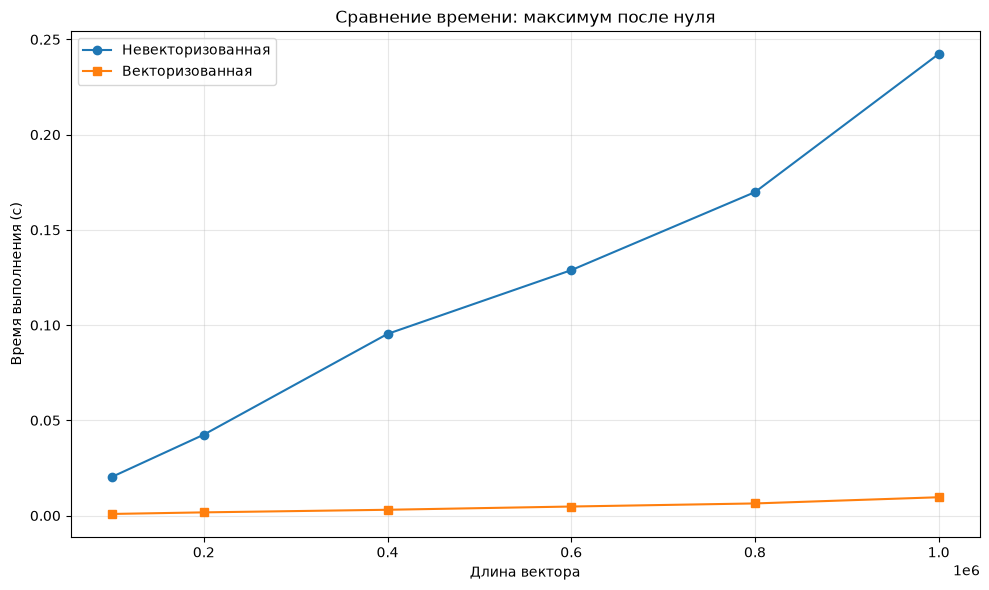

In [26]:
import time
import numpy as np
import matplotlib.pyplot as plt


def max_after_zero(x):
    """Find max element after zero in array.

    input:
    x -- 1-d numpy array
    output:
    maximum element after zero -- integer number

    Not vectorized implementation.
    """
    max_val = None
    for i in range(1, len(x)):
        if x[i - 1] == 0:
            val = x[i]
            if max_val is None or val > max_val:
                max_val = val
    return max_val


def max_after_zero_vec(x):
    """Find max element after zero in array.

    input:
    x -- 1-d numpy array
    output:
    maximum element after zero -- integer number

    Vectorized implementation.
    """
    mask = x[:-1] == 0
    candidates = x[1:][mask]
    if candidates.size == 0:
        return None
    return np.max(candidates)


sizes = [100000, 200000, 400000, 600000, 800000, 1000000]

times_non_vec = []
times_vec = []

for n in sizes:
    x = np.random.randint(0, 1000, size=n)
    zero_indices = np.random.choice(n, size=int(n * 0.6), replace=False)
    x[zero_indices] = 0

    start = time.perf_counter()
    max_after_zero(x)
    times_non_vec.append(time.perf_counter() - start)

    start = time.perf_counter()
    max_after_zero_vec(x)
    times_vec.append(time.perf_counter() - start)

plt.figure(figsize=(10, 6))
plt.plot(sizes, times_non_vec, marker='o', label='Невекторизованная')
plt.plot(sizes, times_vec, marker='s', label='Векторизованная')
plt.title('Сравнение времени: максимум после нуля')
plt.xlabel('Длина вектора')
plt.ylabel('Время выполнения (с)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

 
 
* __Задача 4__: Дан трёхмерный массив, содержащий изображение, размера (height, width, numChannels), а также вектор длины numChannels. Сложить каналы изображения с указанными весами, и вернуть результат в виде матрицы размера (height, width). В ноутбуке приведите пример работы функции – преобразуйте цветное изображение в оттенки серого, использовав коэффициенты np.array([0.299, 0.587, 0.114]). Считать реальное изображение можно с помощью `PIL.Image.open` из пакета Pillow: `img = np.asarray(Image.open(path).convert("RGB"))`. Устаревшая функция `scipy.misc.imread` удалена из современных версий SciPy.


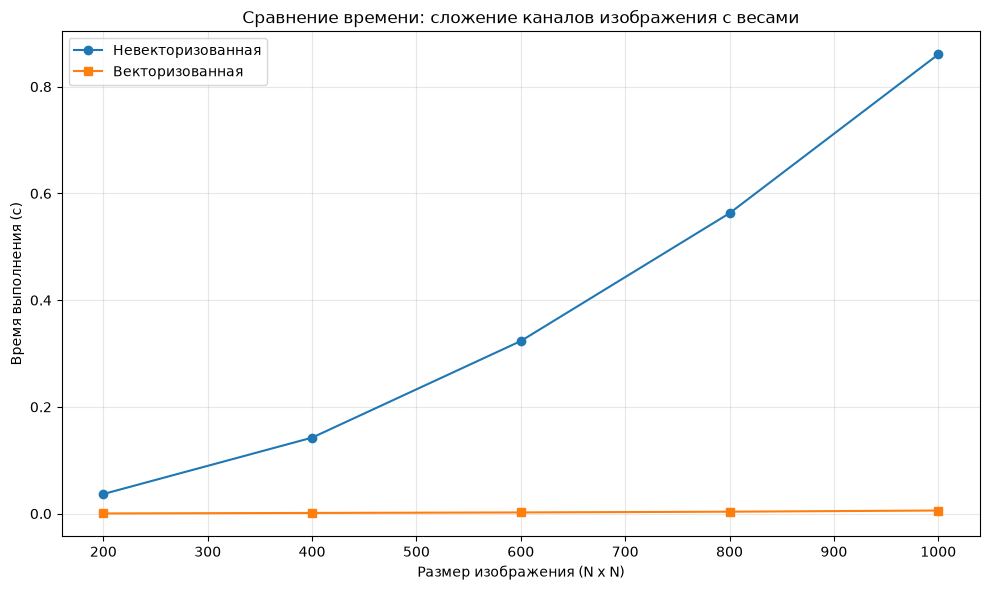

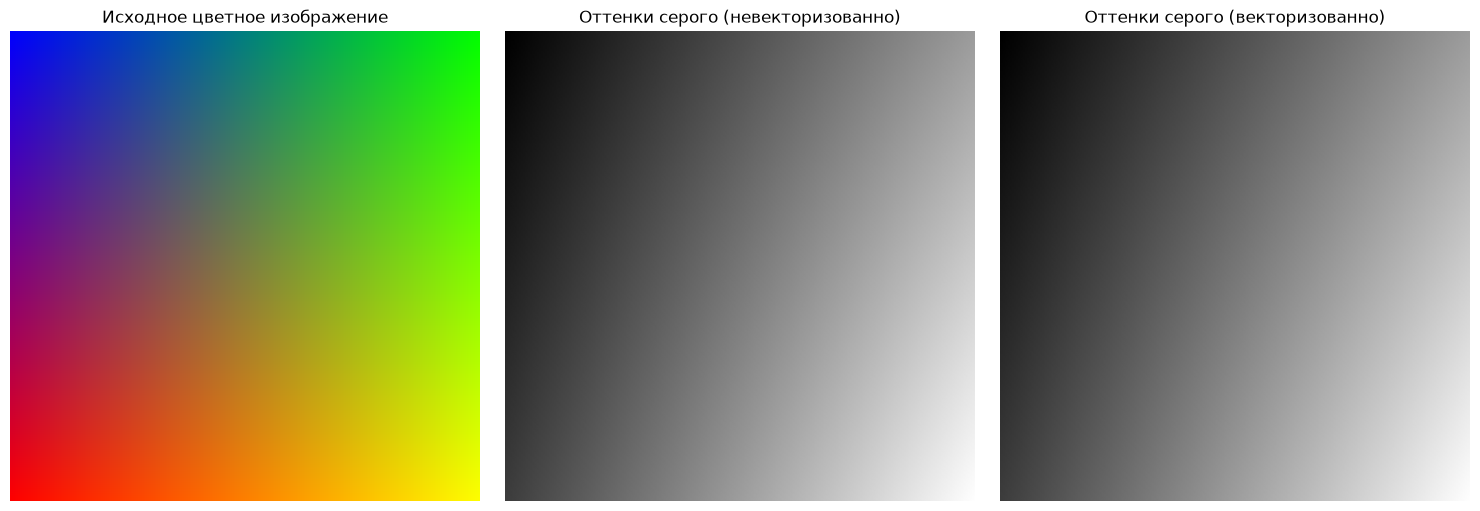

In [10]:
import time
import numpy as np
import matplotlib.pyplot as plt


def convert_image(img, coefs):
    """Sum up image channels with weights from coefs array

    input:
    img -- 3-d numpy array (H x W x C)
    coefs -- 1-d numpy array (length C)
    output:
    img -- 2-d numpy array (H x W)

    Not vectorized implementation.
    """
    H, W, C = img.shape
    result = np.zeros((H, W), dtype=float)
    for i in range(H):
        for j in range(W):
            s = 0.0
            for c in range(C):
                s += img[i, j, c] * coefs[c]
            result[i, j] = s
    return result


def convert_image_vec(img, coefs):
    """Sum up image channels with weights from coefs array

    input:
    img -- 3-d numpy array (H x W x C)
    coefs -- 1-d numpy array (length C)
    output:
    img -- 2-d numpy array (H x W)

    Vectorized implementation.
    """
    return np.tensordot(img, coefs, axes=([2], [0]))


sizes = [200, 400, 600, 800, 1000]
coefs = np.array([0.299, 0.587, 0.114])

times_non_vec = []
times_vec = []

for n in sizes:
    img = np.random.randint(0, 256, size=(n, n, 3), dtype=np.uint8)

    start = time.perf_counter()
    convert_image(img, coefs)
    times_non_vec.append(time.perf_counter() - start)

    start = time.perf_counter()
    convert_image_vec(img, coefs)
    times_vec.append(time.perf_counter() - start)

plt.figure(figsize=(10, 6))
plt.plot(sizes, times_non_vec, marker='o', label='Невекторизованная')
plt.plot(sizes, times_vec, marker='s', label='Векторизованная')
plt.title('Сравнение времени: сложение каналов изображения с весами')
plt.xlabel('Размер изображения (N x N)')
plt.ylabel('Время выполнения (с)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


H, W = 1000, 1000
img = np.zeros((H, W, 3), dtype=np.uint8)

for i in range(H):
    for j in range(W):
        img[i, j, 0] = int(i*255/(H-1))
        img[i, j, 1] = int(j*255/(W-1))
        img[i, j, 2] = int((H-1-i)*(W-1-j)*255/(H-1)/(W-1))

gray_non_vec = convert_image(img, coefs)
gray_vec = convert_image_vec(img, coefs)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img)
axes[0].set_title("Исходное цветное изображение")
axes[0].axis("off")

axes[1].imshow(gray_non_vec, cmap="gray")
axes[1].set_title("Оттенки серого (невекторизованно)")
axes[1].axis("off")

axes[2].imshow(gray_vec, cmap="gray")
axes[2].set_title("Оттенки серого (векторизованно)")
axes[2].axis("off")

plt.tight_layout()
plt.show()

* __Задача 5__: Реализовать кодирование длин серий (Run-length encoding). Для некоторого вектора x необходимо вернуть кортеж из двух векторов одинаковой длины. Первый содержит числа, а второй - сколько раз их нужно повторить.  
 Например, для x = np.array([2, 2, 2, 3, 3, 3, 5]) ответ – (np.array([2, 3, 5]), np.array([3, 3, 1])).

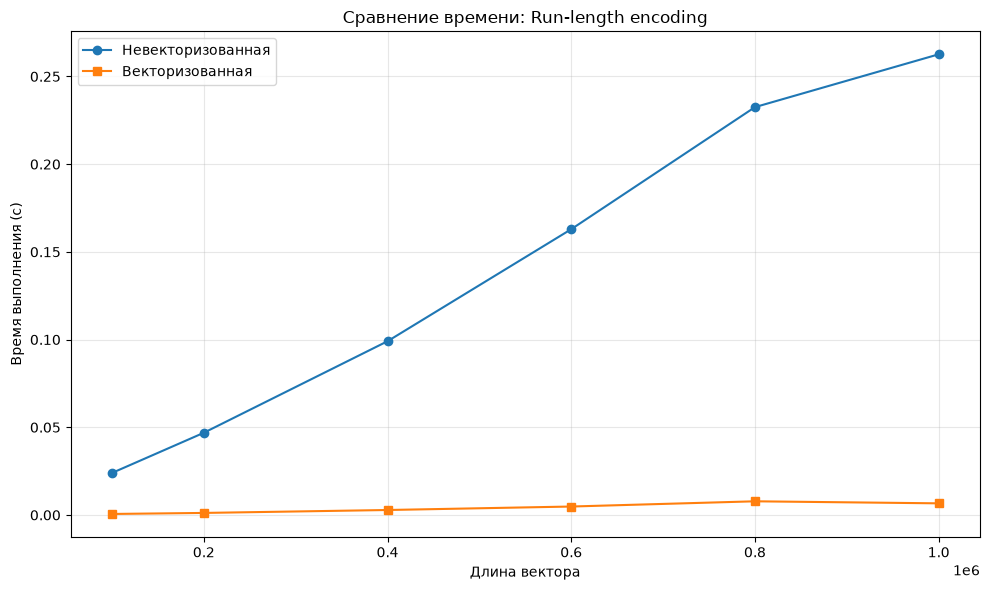

In [3]:
import time
import numpy as np
import matplotlib.pyplot as plt


def run_length_encoding(x):
    if len(x) == 0:
        return np.array([]), np.array([])
    elements = [x[0]]
    counters = [1]
    for i in range(1, len(x)):
        if x[i] == x[i - 1]:
            counters[-1] += 1
        else:
            elements.append(x[i])
            counters.append(1)
    return np.array(elements), np.array(counters)


def run_length_encoding_vec(x):
    if len(x) == 0:
        return np.array([]), np.array([])
    change = np.where(x[1:] != x[:-1])[0] + 1
    start = np.concatenate(([0], change))
    end = np.concatenate((change, [len(x)]))
    elements = x[start]
    counters = end - start
    return elements, counters


sizes = [100000, 200000, 400000, 600000, 800000, 1000000]

times_non_vec = []
times_vec = []

for n in sizes:
    x = np.random.randint(0, 10, size=n)

    start = time.perf_counter()
    run_length_encoding(x)
    times_non_vec.append(time.perf_counter() - start)

    start = time.perf_counter()
    run_length_encoding_vec(x)
    times_vec.append(time.perf_counter() - start)

plt.figure(figsize=(10, 6))
plt.plot(sizes, times_non_vec, marker='o', label='Невекторизованная')
plt.plot(sizes, times_vec, marker='s', label='Векторизованная')
plt.title('Сравнение времени: Run-length encoding')
plt.xlabel('Длина вектора')
plt.ylabel('Время выполнения (с)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

 
 
* __Задача 6__: Даны две выборки объектов - X и Y. Вычислить матрицу евклидовых расстояний между объектами. Дополнительно сравните с функцией scipy.spatial.distance.cdist по скорости работы (сравнения приведите ниже в ноутбуке).

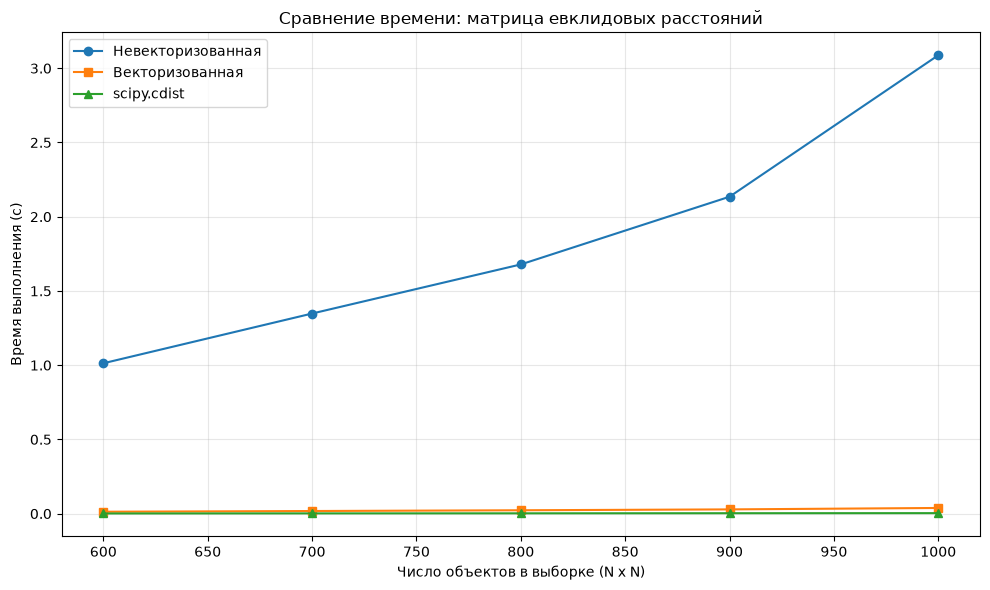

In [2]:
import time
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist


def pairwise_distance_non_vec(x, y):
    n_x = x.shape[0]
    n_y = y.shape[0]
    result = np.zeros((n_x, n_y), dtype=float)
    for i in range(n_x):
        for j in range(n_y):
            diff = x[i] - y[j]
            result[i, j] = np.sum(diff * diff)
    return result


def pairwise_distance_vec(x, y):
    diff = x[:, np.newaxis, :] - y[np.newaxis, :, :]
    return np.sqrt(np.sum(diff ** 2, axis=2))


np.random.seed(0)
X_small = np.random.randn(5, 3)
Y_small = np.random.randn(4, 3)

d_non_vec = pairwise_distance_non_vec(X_small, Y_small)
d_vec = pairwise_distance_vec(X_small, Y_small)
d_cdist = cdist(X_small, Y_small, metric='euclidean')

sizes = [600, 700, 800, 900, 1000]  
n_features = 10

times_non_vec = []
times_vec = []
times_cdist = []

for n in sizes:
    X = np.random.randn(n, n_features)
    Y = np.random.randn(n, n_features)

    start = time.perf_counter()
    pairwise_distance_non_vec(X, Y)
    times_non_vec.append(time.perf_counter() - start)

    start = time.perf_counter()
    pairwise_distance_vec(X, Y)
    times_vec.append(time.perf_counter() - start)

    start = time.perf_counter()
    cdist(X, Y, metric='euclidean')
    times_cdist.append(time.perf_counter() - start)

plt.figure(figsize=(10, 6))
plt.plot(sizes, times_non_vec, marker='o', label='Невекторизованная')
plt.plot(sizes, times_vec, marker='s', label='Векторизованная')
plt.plot(sizes, times_cdist, marker='^', label='scipy.cdist')
plt.title('Сравнение времени: матрица евклидовых расстояний')
plt.xlabel('Число объектов в выборке (N x N)')
plt.ylabel('Время выполнения (с)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### Туториал по Markdown

__(1 балл)__

Напишите краткий (а в данной домашке ещё и почти бесмысленный) отчёт с использованием 4-5 различных вариантов разметки/выделения текста.

В ходе работы выполнены **шесть задач** по векторизации вычислений с использованием `numpy`. Для каждой задачи написаны две реализации: невекторизованная и векторизованная. Время работы сравнивалось с помощью `matplotlib`, а для задачи с расстояниями дополнительно привлекалась `scipy.spatial.distance.cdist`. Результаты показали, что векторизация даёт ускорение в разы, а `cdist` часто обгоняет даже ручную векторизацию.